# Lab: Exploratory Decision Trees — Wine Dataset (Student Worksheet)

**Objective:** Build intuition for how a Decision Tree Classifier actually behaves —
not just how to call `.fit()`. You will explore split criteria (Gini vs Entropy),
tree depth, and other hyperparameters to find the configuration that generalizes best.

**Dataset:** Wine — 178 samples, 13 numeric features, 3-class target (three different
cultivars of wine grown in the same region of Italy), built into `sklearn.datasets`.
Unlike the Breast Cancer dataset used in the previous lab, this is a **multiclass**
problem, not binary — several ideas (confusion matrices, per-class error types) look a
little different with 3 classes instead of 2.

**How this notebook works:** Sections 1-3 (Setup, EDA, Baseline) are fully worked for
you — run them as-is, they set up everything you need. From Section 4 onward, cells
marked **`# TODO`** contain instructions but *no solution code* — you write that part
yourself. Later cells often depend on variable names introduced in an earlier TODO
(the instructions tell you what name to use), so work through the sections in order.

---
## 1. Setup & Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
np.random.seed(42)

RANDOM_STATE = 42

In [ ]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0, 1, 2 = the three cultivars

print("Shape:", X.shape)
print("Classes:", dict(zip(data.target_names, [0, 1, 2])))
print(y.value_counts().sort_index())
X.head()

Shape: (178, 13)
Classes: {np.str_('class_0'): 0, np.str_('class_1'): 1, np.str_('class_2'): 2}
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


---
## 2. Quick EDA

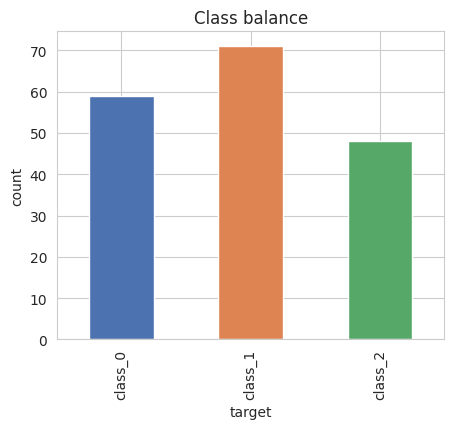

target
0    0.331
1    0.399
2    0.270
Name: proportion, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().sort_index().rename({0: data.target_names[0], 1: data.target_names[1], 2: data.target_names[2]}) \
    .plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

print(y.value_counts(normalize=True).sort_index().round(3))

::**TODO (reflection):** Is this dataset balanced or imbalanced across its three
classes? How does a "predict the majority class every time" baseline accuracy compare
here to the ~63% floor the Breast Cancer dataset had in the previous lab? Keep this in
mind — you'll come back to it in Section 8 when judging whether a model's accuracy
number alone tells the full story.

*Your answer:* — *(replace this line)*

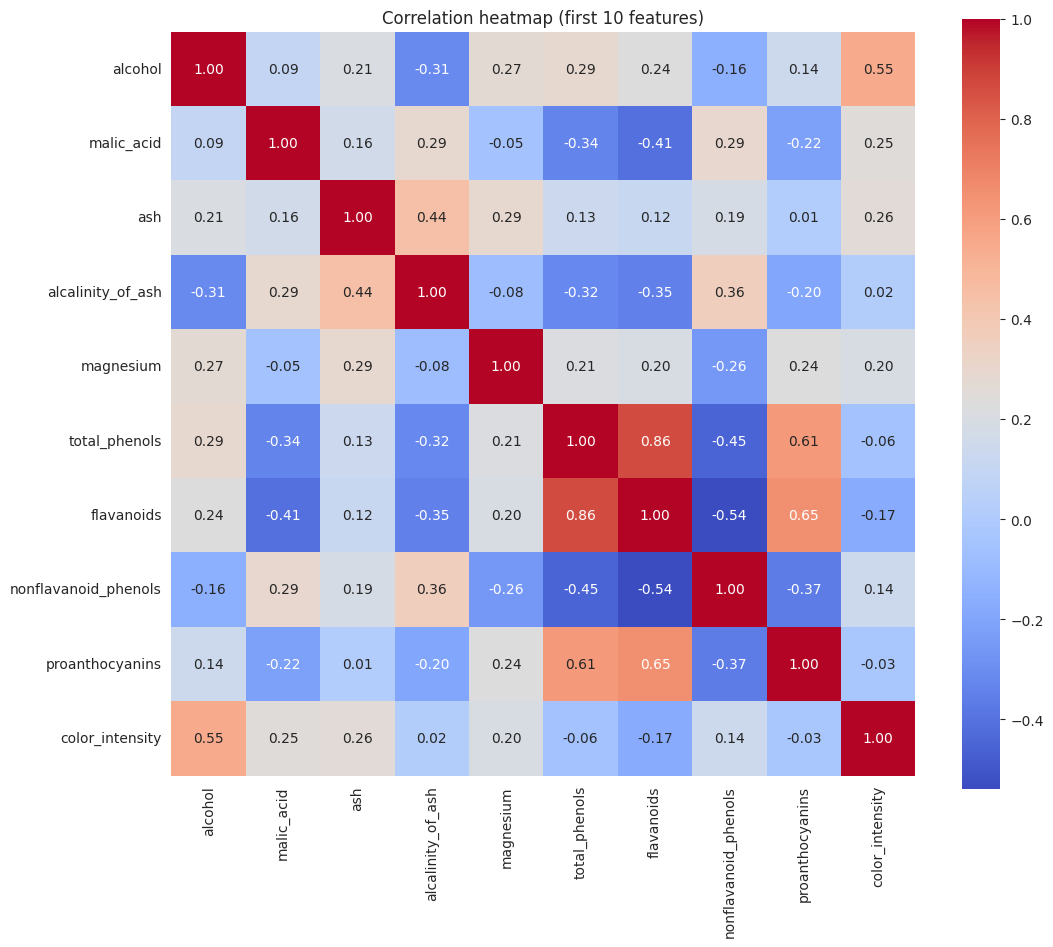

In [ ]:
plt.figure(figsize=(12, 10))
corr = X.iloc[:, :10]  # first 10 of 13 features
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (first 10 features)")
plt.show()

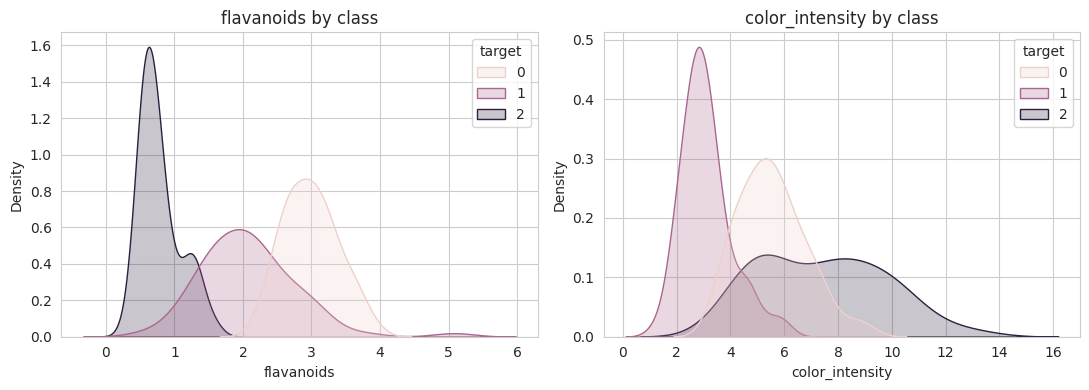

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['flavanoids', 'color_intensity']):
    sns.kdeplot(data=X.assign(target=y), x=feat, hue='target', fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{feat} by class")
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Train test split first, then fit a plain, default-parameter `DecisionTreeClassifier`.
Everything after this cell is measured against this baseline.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (142, 13)  Test: (36, 13)


In [ ]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Baseline tree depth:", baseline_model.get_depth(), " | leaves:", baseline_model.get_n_leaves())
print()
print(classification_report(y_test, baseline_pred, target_names=data.target_names))

Baseline accuracy: 0.9444
Baseline tree depth: 4  | leaves: 8

              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



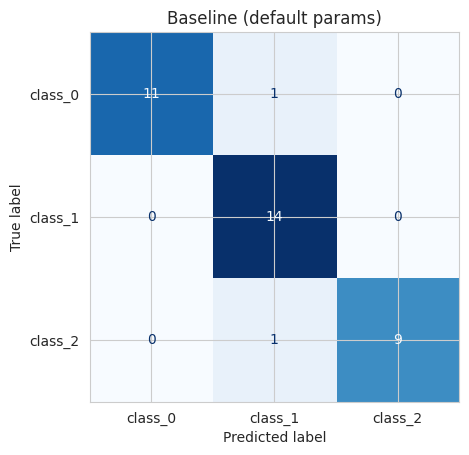

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

In [ ]:
def plot_confusion(model, X_te, y_te, title):
    """Reusable confusion matrix plotter -- you'll call this throughout the rest of the lab."""
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()
    return cm

plot_confusion(baseline_model, X_test, y_test, "Baseline (default params)")

---
## 4. Gini vs Entropy

Same tree, same split, only the impurity measure changes.

In [ ]:
# TODO: train one DecisionTreeClassifier per criterion in ['gini', 'entropy']
#       (same random_state=RANDOM_STATE, no other params changed).
#       For each, compute test-set accuracy and store it in a dict:
#           criterion_results = {'gini': <acc>, 'entropy': <acc>}
#       Print each criterion name, its accuracy, and the resulting tree depth
#       (hint: model.get_depth()).
#
# criterion_results = {}
# ...your code here...

criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=RANDOM_STATE
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate test accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store accuracy
    criterion_results[criterion] = accuracy

    # Print results
    print(f"Criterion: {criterion}")
    print(f"Test accuracy: {accuracy:.4f}")
    print(f"Tree depth: {model.get_depth()}")
    print()

print("criterion_results =", criterion_results)


Criterion: gini
Test accuracy: 0.9444
Tree depth: 4

Criterion: entropy
Test accuracy: 0.9722
Tree depth: 4

criterion_results = {'gini': 0.9444444444444444, 'entropy': 0.9722222222222222}


**TODO (reflection):** Gini and Entropy are both impurity measures but computed
differently (Gini: `1 - sum(p_i^2)`, Entropy: `-sum(p_i * log2(p_i))`). Did they produce
the same accuracy here? If so, does that mean they always pick the same splits — or just
that this dataset doesn't stress the difference? Write 2-3 sentences.

*Your answer:* — *(replace this line)*

---
## 5. Depth Exploration — the core overfitting curve

Sweep `max_depth` from 1 to 20 and track **train** and **test** accuracy separately.
This is the single most important plot in the lab.

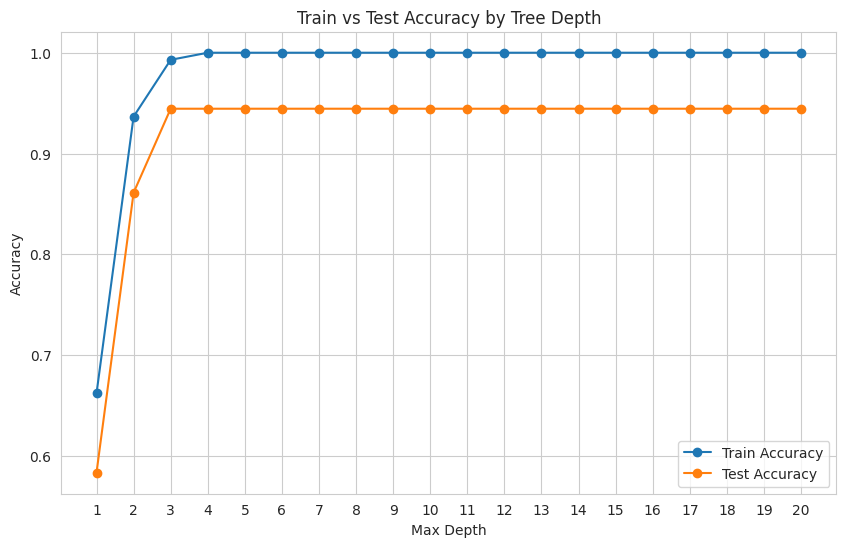

In [ ]:
  # TODO: sweep max_depth over range(1, 21). For each depth, train a
  #       DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE), and
  #       record both train accuracy and test accuracy in two lists:
  #           train_accs = [...]
  #           test_accs = [...]
  #       Plot both lists against depth on one figure (train vs test accuracy).
  #
  # depths = range(1, 21)
  # train_accs, test_accs = [], []
  # ...your code here...
depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=RANDOM_STATE
    )

    # Train the model
    model.fit(X_train, y_train)

    # Calculate training accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_accs.append(train_acc)

    # Calculate test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_accs.append(test_acc)

# Plot train vs test accuracy
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy')
plt.plot(depths, test_accs, marker='o', label='Test Accuracy')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# TODO: from train_accs/test_accs above, find the depth with the highest
#       test accuracy. Store it as `best_depth_by_test` (later cells use this
#       exact name) along with the training accuracy at that same depth.
#       Print both values.
#
# best_depth_by_test = ...
# Find the index of the highest test accuracy
best_index = np.argmax(test_accs)

# Get the corresponding depth
best_depth_by_test = list(depths)[best_index]

# Get training accuracy at the same depth
best_train_acc = train_accs[best_index]

print(f"Best depth by test accuracy: {best_depth_by_test}")
print(f"Test accuracy: {test_accs[best_index]:.4f}")
print(f"Training accuracy at that depth: {best_train_acc:.4f}")

Best depth by test accuracy: 3
Test accuracy: 0.9444
Training accuracy at that depth: 0.9930


---
## 6. Accuracy vs Depth, split by Criterion

Same sweep, but gini and entropy plotted separately — does the optimal depth shift?

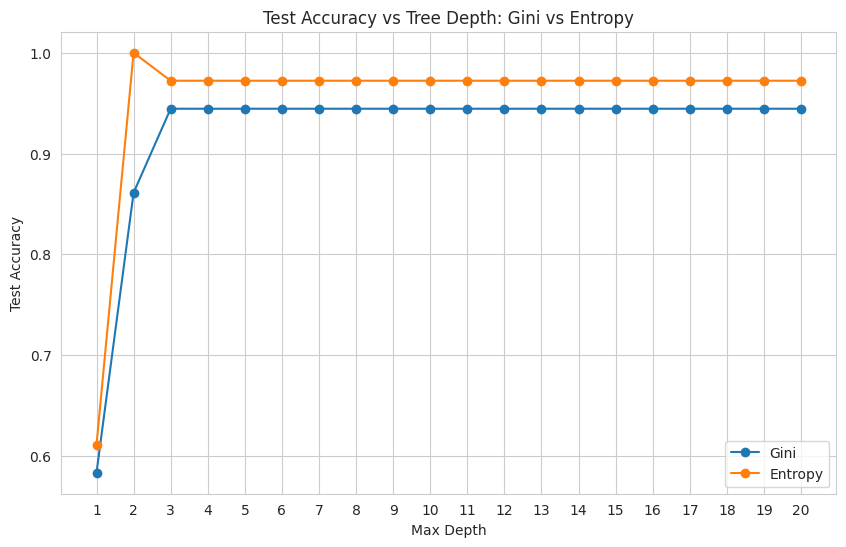

Best criterion: entropy
Best depth: 2
Best test accuracy: 1.0000


In [ ]:
# TODO: repeat the depth sweep from Section 5, but this time for BOTH
#       criteria ('gini' and 'entropy'), tracking TEST accuracy only.
#       Store results as a nested structure, using this exact name:
#           depth_criterion_results = {'gini': [...], 'entropy': [...]}
#       (one accuracy value per depth in `depths`, same order)
#       Plot both lines on one figure, labeled by criterion.
#
# depth_criterion_results = {}
# ...your code here...

# TODO: from depth_criterion_results, find the single best (criterion, depth)
#       pair (highest test accuracy overall). Store them as `best_c` and
#       `best_d` (later cells use these exact names) and print them.
#
# best_c = ...
# best_d = ...

depth_criterion_results = {}

for criterion in ['gini', 'entropy']:
    depth_criterion_results[criterion] = []

    for d in depths:
        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=d,
            random_state=RANDOM_STATE
        )

        # Train the model
        model.fit(X_train, y_train)

        # Test accuracy
        test_pred = model.predict(X_test)
        test_acc = accuracy_score(y_test, test_pred)

        # Store accuracy
        depth_criterion_results[criterion].append(test_acc)

# Plot both criteria
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    depth_criterion_results['gini'],
    marker='o',
    label='Gini'
)

plt.plot(
    depths,
    depth_criterion_results['entropy'],
    marker='o',
    label='Entropy'
)

plt.xlabel('Max Depth')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs Tree Depth: Gini vs Entropy')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()

best_c = None
best_d = None
best_acc = -1

for criterion in ['gini', 'entropy']:
    for i, d in enumerate(depths):
        accuracy = depth_criterion_results[criterion][i]

        if accuracy > best_acc:
            best_acc = accuracy
            best_c = criterion
            best_d = d

print(f"Best criterion: {best_c}")
print(f"Best depth: {best_d}")
print(f"Best test accuracy: {best_acc:.4f}")


---
## 7. Pruning — cost-complexity as an alternative to early stopping

`max_depth` stops the tree from growing past a certain point. Cost-complexity
pruning does the opposite: grow the full tree, then trim it back afterward
using `ccp_alpha`. Same goal (control overfitting), different mechanism.

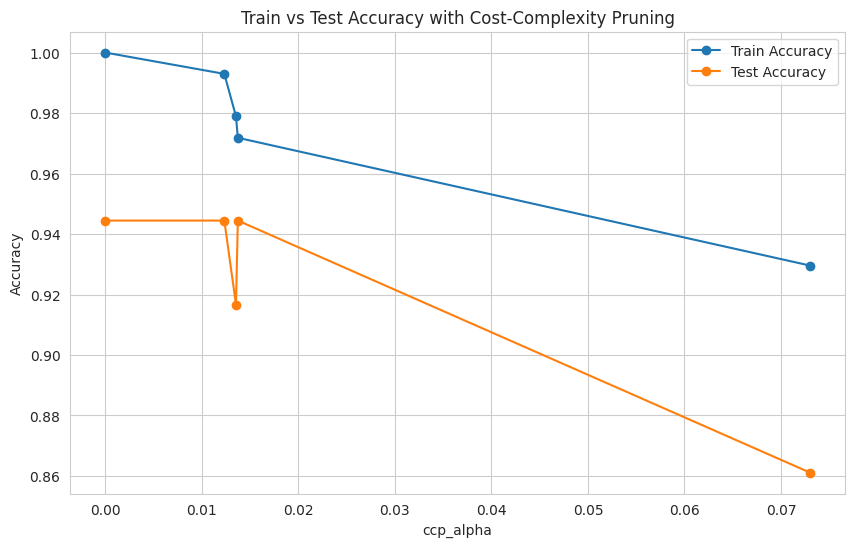

In [ ]:
# TODO: cost-complexity pruning. Use
#           DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
#       to get `.ccp_alphas` (drop the last, trivial single-node alpha).
#       For each alpha, train a tree with that ccp_alpha and record BOTH train
#       and test accuracy. Plot both curves vs alpha.
#
# pruning_path = ...
# ccp_alphas = ...
# ...your code here...
# Get the cost-complexity pruning path
pruning_path = DecisionTreeClassifier(
    random_state=RANDOM_STATE
).cost_complexity_pruning_path(X_train, y_train)

# Get ccp_alpha values and drop the last one
# The last alpha produces a trivial single-node tree
ccp_alphas = pruning_path.ccp_alphas[:-1]

train_accs_pruned = []
test_accs_pruned = []

# Train a tree for each alpha
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    # Training accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_accs_pruned.append(train_acc)

    # Test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_accs_pruned.append(test_acc)

# Plot train vs test accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    train_accs_pruned,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    ccp_alphas,
    test_accs_pruned,
    marker='o',
    label='Test Accuracy'
)

plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy with Cost-Complexity Pruning')
plt.legend()
plt.grid(True)
plt.show()


**TODO (reflection):** `ccp_alpha` prunes a fully-grown tree after the fact,
instead of stopping it early like `max_depth` does. Compare this curve's shape
to the depth curve in Section 5 — same story, or different?

*Your answer:* — *(replace this line)*

---
## 8. Confusion Matrix Deep-Dive

Compare confusion matrices at a **shallow**, **near-optimal**, and **overly deep** tree
using the `plot_confusion()` function defined back in Section 3. With 3 classes
instead of 2, each confusion matrix is now 3×3 — there is no single "false positive vs
false negative" axis anymore, so look at *which specific pair of cultivars* gets
confused for one another.

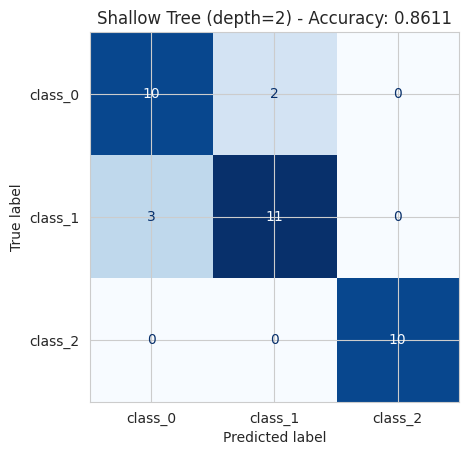

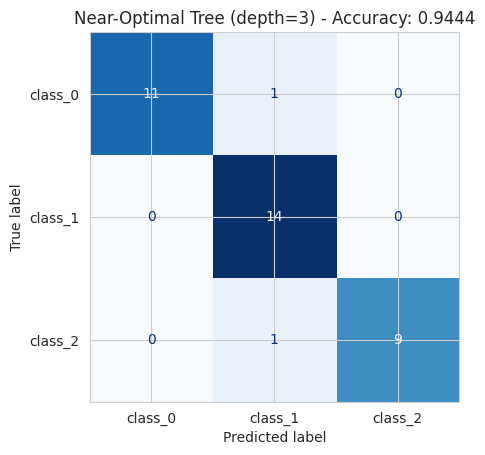

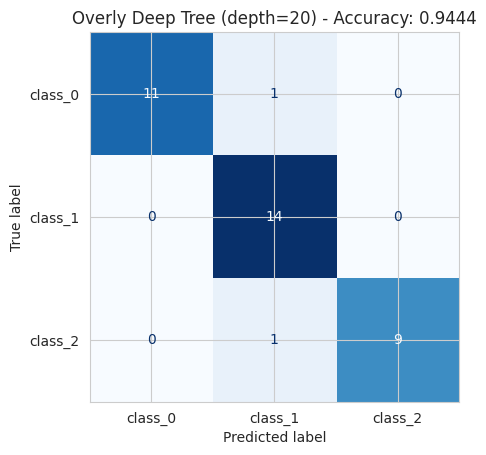

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

In [ ]:
# TODO: train three models on X_train/y_train:
#         - a "shallow" tree with max_depth=2
#         - a "near-optimal" tree with max_depth=best_depth_by_test (from Section 5)
#         - an "overly deep" tree with max_depth=20
#       For each, compute test accuracy and call plot_confusion(model, X_test,
#       y_test, <a descriptive title including the accuracy>).
#
# shallow_model = ...
# best_model_depth_only = ...
# deep_model = ...
# ...your code here...
# Shallow tree
shallow_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

shallow_model.fit(X_train, y_train)

shallow_pred = shallow_model.predict(X_test)
shallow_acc = accuracy_score(y_test, shallow_pred)

plot_confusion(
    shallow_model,
    X_test,
    y_test,
    f"Shallow Tree (depth=2) - Accuracy: {shallow_acc:.4f}"
)


# Near-optimal tree
best_model_depth_only = DecisionTreeClassifier(
    max_depth=best_depth_by_test,
    random_state=RANDOM_STATE
)

best_model_depth_only.fit(X_train, y_train)

best_pred = best_model_depth_only.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)

plot_confusion(
    best_model_depth_only,
    X_test,
    y_test,
    f"Near-Optimal Tree (depth={best_depth_by_test}) - Accuracy: {best_acc:.4f}"
)


# Overly deep tree
deep_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=RANDOM_STATE
)

deep_model.fit(X_train, y_train)

deep_pred = deep_model.predict(X_test)
deep_acc = accuracy_score(y_test, deep_pred)

plot_confusion(
    deep_model,
    X_test,
    y_test,
    f"Overly Deep Tree (depth=20) - Accuracy: {deep_acc:.4f}"
)


**TODO (reflection):** The accuracy numbers alone might look similar across these
three models. Do the confusion matrices tell a more interesting story than the
accuracy number does? Specifically: with 3 classes, is there one pair of cultivars
that gets confused more often than the others, across all three models? Does that
confusion get worse, better, or stay the same as depth increases past the sweet spot?

*Your answer:* — *(replace this line)*

---
## 9. Grid Search

Search jointly over criterion and depth parameters using
5-fold cross-validation on the training set.

In [ ]:
# TODO: build a param_grid dict covering:
#           criterion: ['gini', 'entropy']
#           max_depth: [3, 4, 5, 6, 7, 8, None]
#
#       Then run GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
#       param_grid, cv=5, scoring='accuracy', n_jobs=-1) on X_train/y_train.
#       Print grid_search.best_params_ and grid_search.best_score_.
#
#       This grid has 2 criteria × 7 depths = 14 combinations. With `cv=5`, that means
#       `GridSearchCV` will fit 14 × 5 = 70 models total — which is why this cell takes
#       noticeably longer to run than any single `.fit()` call earlier in the lab.
#
# param_grid = {...}
# grid_search = ...
# ...your code here...

# Define the hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, None]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Run grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best cross-validation score
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 3}
Best CV accuracy: 0.9231527093596059


Section 3 Baseline Accuracy: 0.9444
Section 6 Manual Best Accuracy: 0.9444
GridSearchCV Best Model Accuracy: 0.9444


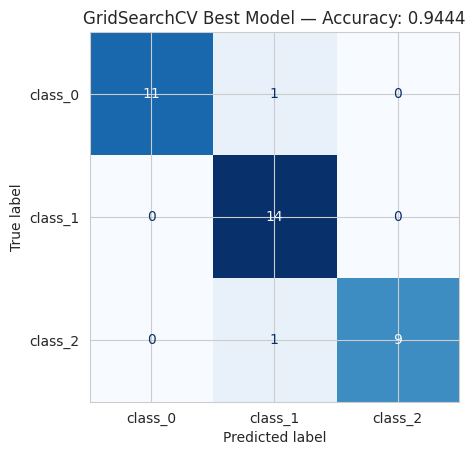

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

In [ ]:
# TODO: pull grid_search.best_estimator_ into `best_model` (later cells use
#       this exact name). Compute its held-out test accuracy, print it next
#       to the Section 3 baseline accuracy and your manual best from Section 6,
#       and call plot_confusion() on it.
#
# best_model = ...
# ...your code here...
# Get the best model found by GridSearchCV
# Get the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Compute held-out test accuracy
best_model_pred = best_model.predict(X_test)
best_model_acc = accuracy_score(y_test, best_model_pred)

# Print comparison of model accuracies
print(f"Section 3 Baseline Accuracy: {baseline_acc:.4f}")
print(f"Section 6 Manual Best Accuracy: {best_acc:.4f}")
print(f"GridSearchCV Best Model Accuracy: {best_model_acc:.4f}")

# Plot confusion matrix
plot_confusion(
    best_model,
    X_test,
    y_test,
    f"GridSearchCV Best Model — Accuracy: {best_model_acc:.4f}"
)

**TODO (reflection, no code):** Did GridSearchCV beat your manual exploration from
Sections 4-7? If not, why might that be, given cross-validation vs a single
train/test split?

*Your answer:* — *(replace this line)*

---
## 10. Bonus — Feature Importance & Tree Visualization

Section 3 Baseline Accuracy: 0.9444
Section 6 Manual Best Accuracy: 0.9444
GridSearchCV Best Model Accuracy: 0.9444


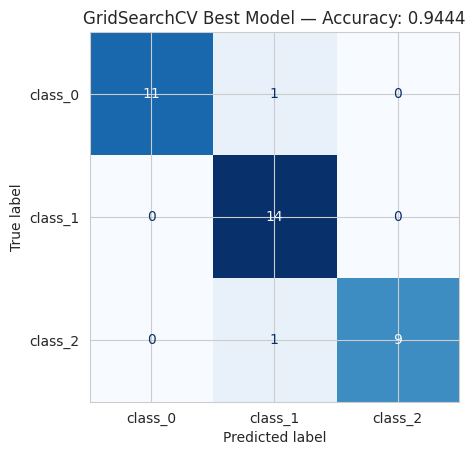

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

In [ ]:
# TODO: using best_model.feature_importances_, build a DataFrame with columns
#       'Feature' and 'Importance', sort it descending, and bar-plot the top 10.
#       (There are only 13 features total here, so "top 10" covers most of them —
#       that's expected.)
#
# importance = ...
# ...your code here...
# Get the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Compute held-out test accuracy
best_model_pred = best_model.predict(X_test)
best_model_acc = accuracy_score(y_test, best_model_pred)

# Print comparison of model accuracies
print(f"Section 3 Baseline Accuracy: {baseline_acc:.4f}")
print(f"Section 6 Manual Best Accuracy: {best_acc:.4f}")
print(f"GridSearchCV Best Model Accuracy: {best_model_acc:.4f}")

# Plot confusion matrix
plot_confusion(
    best_model,
    X_test,
    y_test,
    f"GridSearchCV Best Model — Accuracy: {best_model_acc:.4f}"
)

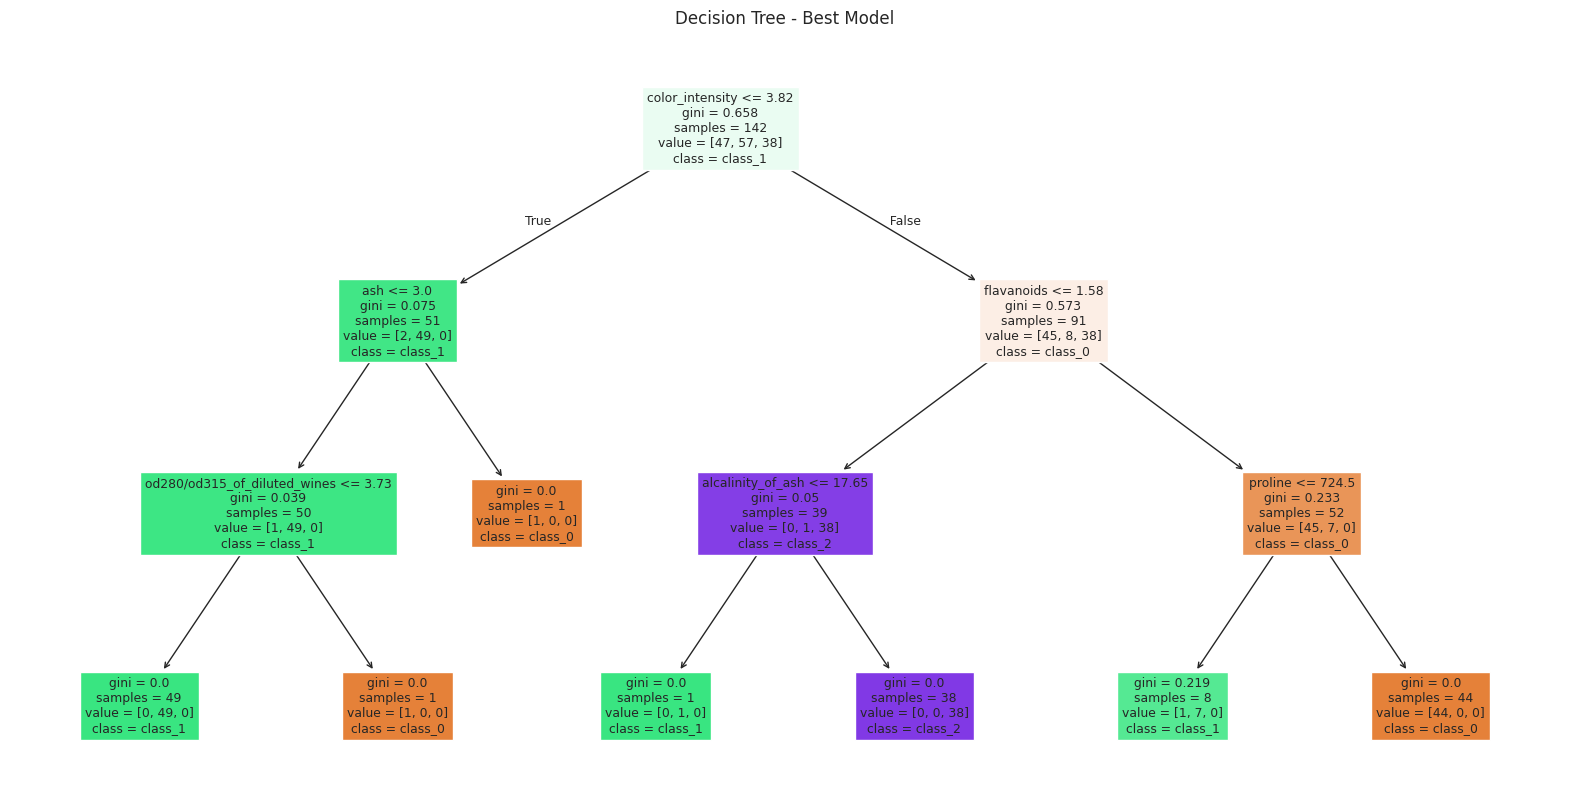

In [ ]:
# TODO: use sklearn.tree.plot_tree() to visualize best_model. Pass
#       feature_names=X.columns, class_names=data.target_names, filled=True,
#       and max_depth=3 (the full tree may be unreadable otherwise).
#
# ...your code here...
plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)

plt.title("Decision Tree - Best Model")
plt.show()


**TODO (reflection, no code):** Does the root-node split use one of the top-3 features
from the importance bar chart above? It should — explain in one sentence why
that's not a coincidence.

*Your answer:* — *(replace this line)*

---
## 11. Reflection / Write-up

Answer each of these in 2-4 sentences.

1. **Which hyperparameter had the biggest effect on overfitting — depth, criterion or ccp_alpha?** What made you pick that one?

   *Your answer:* — *Depth had the biggest effect on overfitting. As depth increased, training accuracy quickly reached 100%, while test accuracy stopped improving around depth 3, showing a clear train/test gap. Criterion had a smaller effect, while ccp_alpha also controlled complexity but did not improve the test accuracy beyond the best depth.*

2. **Did Gini and Entropy ever meaningfully disagree** — on accuracy, depth, or which
   feature got picked at the root? Or did they behave almost identically throughout?

   *Your answer:* — *Yes, they differed somewhat in this experiment. Gini achieved about 94.44% test accuracy with a depth-4 tree, while Entropy achieved about 97.22% with a depth-4 tree. They also selected different root features, showing that the impurity measure can affect the tree structure.*

3. **What would you tell someone who just maximizes test-set accuracy blindly**, without
   looking at confusion matrices or train/test gaps? Use something specific you observed
   in this lab (Section 8 or Section 9) to back up your answer.

   *Your answer:* — *They should also examine confusion matrices and the gap between training and test accuracy. In this lab, deeper trees reached 100% training accuracy without improving test accuracy beyond about 94.44%, so choosing the most complex tree would not provide a real benefit. The confusion matrices also showed that some specific cultivars were confused with each other even when the overall accuracy looked high.*

4. **This dataset has 3 balanced-ish classes instead of 2 imbalanced ones like the Breast
   Cancer dataset from the previous lab.** Did that change anything about how you
   interpreted accuracy, confusion matrices, or feature importances in this lab compared
   to the last one?

   *Your answer:* — *Yes, because the classes were relatively balanced, accuracy was a more useful overall metric than it would be for a strongly imbalanced dataset. With three classes, the confusion matrix showed exactly which cultivars were being confused rather than just false positives and false negatives. Feature importance also helped identify which chemical features were most useful for separating the three cultivars.*